In [2]:
import pandas as pd

In [3]:
invoice = pd.read_csv("fct_invoice.csv")
customers = pd.read_json("dim_customer.json")

Easy 1: unique customers purchased items in invoice

In [4]:
invoice.customer_id.nunique()

5191

Easy 2: the different categories and number of unique category

In [5]:
unique = invoice.category.unique()
numberOFcate=invoice.category.nunique()
print(unique)
print(numberOFcate)

['Clothing' 'Shoes' 'Books' 'Cosmetics' 'Food & Beverage' 'Toys'
 'Technology' 'Souvenir']
8


Easy 3: most popular payment method and how many times it was used

In [6]:
mostPAY = invoice.payment_method.value_counts()
mostPAY.head(1)

payment_method
Cash    44447
Name: count, dtype: int64

medium 1:three most popular categories by total sales

In [7]:
invoice["sale"]=invoice.price * invoice.quantity
presort=invoice.groupby("category")["sale"].sum()
presort.sort_values(ascending=False).head(3)

category
Clothing      1.139968e+08
Shoes         6.655345e+07
Technology    5.786235e+07
Name: sale, dtype: float64

medium 2:total sales attributed to customers over 45

In [8]:
age = customers["age"]
mergy = pd.merge(invoice,customers,left_on="customer_id",right_on="id")
mergy.loc[mergy["age"]>45]["sale"].sum()

82039768.15

medium 3:how is the data distributed across different invoice dates?

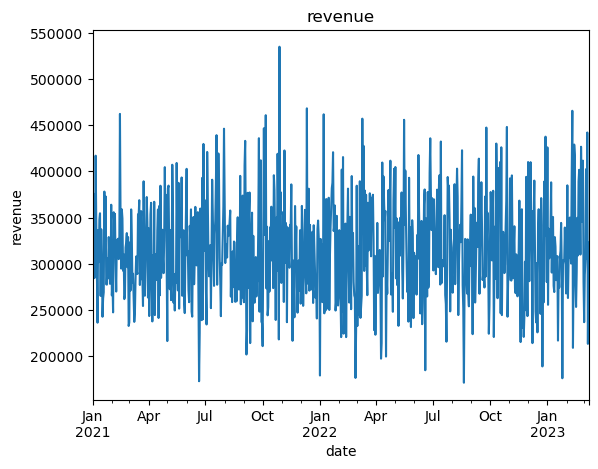

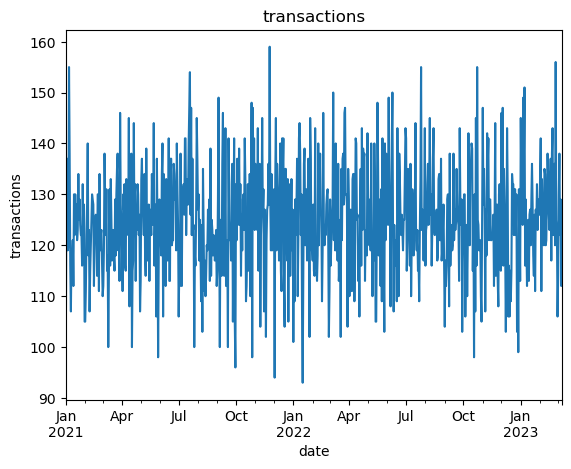

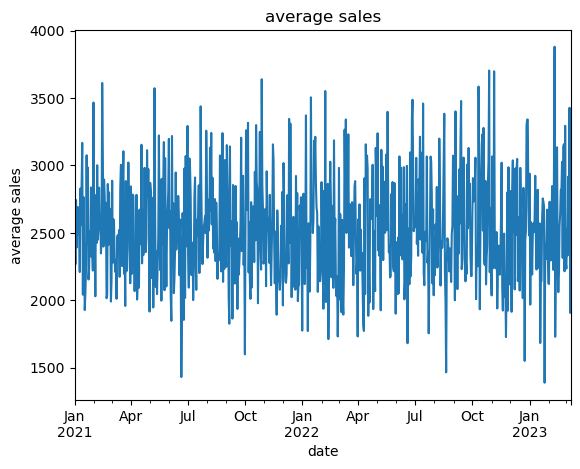

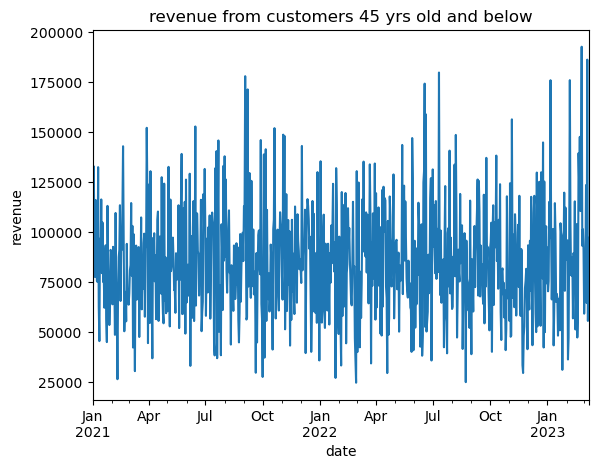

In [72]:
import matplotlib.pyplot as plt
mergy = pd.merge(invoice,customers,left_on="customer_id",right_on="id")
mergy["invoice_date"]=pd.to_datetime(mergy["invoice_date"], format ='%d/%m/%Y')
mergy.sort_values (by = "invoice_date")
mergy["sale"] = mergy["quantity"]*mergy["price"]

mergy.groupby("invoice_date")["sale"].sum().plot(ylabel="revenue",xlabel="date",title="revenue")
plt.show()

mergy.groupby("invoice_date")["quantity"].count().plot(ylabel="transactions",xlabel="date",title="transactions")
plt.show()

mergy.groupby("invoice_date")["sale"].mean().plot(ylabel="average sales",xlabel="date",title="average sales")
plt.show()

lessTHAN45=mergy[mergy["age"]<=45]
lessTHAN45.groupby("invoice_date")["sale"].sum().plot(ylabel="revenue",xlabel="date",title="revenue from customers 45 yrs old and below")
plt.show()




hard: pivot table showing breakdown of sales by category then by decade age range

In [80]:
mergy["sale"] = mergy["quantity"] * mergy["price"]
mergy.loc[mergy["age"].between(10,19),"decade_range"] = "10-19"
mergy.loc[mergy["age"].between(20,29),"decade_range"] = "20-29"
mergy.loc[mergy["age"].between(30,39),"decade_range"] = "30-39"
mergy.loc[mergy["age"].between(40,49),"decade_range"] = "40-49"
mergy.loc[mergy["age"].between(50,59),"decade_range"] = "50-59"
mergy.loc[mergy["age"].between(60,69),"decade_range"] = "60-69"
mergy.loc[mergy["age"].between(70,79),"decade_range"] = "70-79"
mergy.loc[mergy["age"].between(80,89),"decade_range"] = "80-89"
mergy.loc[mergy["age"].between(90,99),"decade_range"] = "90-99"
mergy.pivot_table(values="sale",index="category", columns = "decade_range", aggfunc = sum)



/var/folders/w8/cyw9vq_x4b10gxkjflmc8y7r0000gn/T/ipykernel_1577/2123410805.py:11: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  mergy.pivot_table(values="sale",index="category", columns = "decade_range", aggfunc = sum)


decade_range,10-19,20-29,30-39,40-49,50-59,60-69,70-79,80-89,nan
category,,,,,,,,,
Books,12801.75,79461.75,84143.10,87203.40,74962.20,80476.80,54827.85,26664.00,334012.05
Clothing,1927413.84,10250732.80,11354126.96,11215189.92,10321851.76,10660642.08,7769371.28,4493698.00,46003764.40
Cosmetics,109619.36,605915.32,723544.70,665034.96,587780.96,649990.76,419082.62,254531.60,2777362.62
Food & Beverage,13582.31,73491.96,87246.86,89553.29,72425.04,80976.09,55050.98,31332.93,345875.59
Shoes,993281.35,5924878.24,7200839.66,7025590.02,5852857.84,5978893.54,4480269.05,2628744.60,26468097.17
Souvenir,12375.15,54943.32,64092.72,66391.80,54943.32,55025.43,38673.81,23718.06,265661.04
Technology,1129800.00,5261550.00,6159300.00,5954550.00,4435200.00,5471550.00,3638250.00,1946700.00,23865450.00
Toys,60426.24,385100.80,420582.40,390906.88,345067.52,363955.20,273244.16,153932.80,1587210.24
